In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

In [2]:
covid = pd.read_csv("C:/Users/elzbi/OneDrive/Pulpit/Infoshare Academy/jdszr15-materialy-python/Projekt 2/covid_positive")
df = pd.DataFrame(covid)
covid.sample(20)

,COVID_TEST_RESULT,HOSPITALIZED,INTUBED,ADMITTED_TO_ICU,DEAD,AGE,SEX,PREGNANT,SMOKER,PNEUMONIA,COPD,ASTHMA,IMMUNOSUPPRESSED,CARDIOVASCULAR_DISEASE,HIPERTENSION,CHRONIC_KIDNEY_DISEASE,DIABETES,OBESITY,OTHER_DISEASE
47145,1,1,0.0,0.0,0,58,female,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2625,1,0,NaN,NaN,0,53,male,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
80771,1,1,0.0,0.0,1,73,male,NaN,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
14482,1,1,0.0,0.0,1,73,male,NaN,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0
104800,1,0,NaN,NaN,0,71,female,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
45041,1,1,0.0,0.0,0,44,male,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
28336,1,1,0.0,0.0,1,60,male,NaN,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0
48824,1,1,0.0,0.0,1,78,male,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
62724,1,1,0.0,0.0,0,69,male,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
42899,1,1,0.0,0.0,0,29,male,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


In [3]:
covid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113288 entries, 0 to 113287
Data columns (total 19 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   COVID_TEST_RESULT       113288 non-null  int64  
 1   HOSPITALIZED            113288 non-null  int64  
 2   INTUBED                 75002 non-null   float64
 3   ADMITTED_TO_ICU         74994 non-null   float64
 4   DEAD                    113288 non-null  int64  
 5   AGE                     113288 non-null  int64  
 6   SEX                     113288 non-null  object 
 7   PREGNANT                46901 non-null   float64
 8   SMOKER                  112098 non-null  float64
 9   PNEUMONIA               113284 non-null  float64
 10  COPD                    112218 non-null  float64
 11  ASTHMA                  112222 non-null  float64
 12  IMMUNOSUPPRESSED        112083 non-null  float64
 13  CARDIOVASCULAR_DISEASE  112140 non-null  float64
 14  HIPERTENSION        

In [11]:
def perform_chi_square_test(data, col1, col2):
    # Utworzenie tablicy korelacyjnej (ang. contingency table):
    contingency_table = pd.crosstab(data[col1], data[col2])

    # Przeprowadzenie testu chi-kwadrat (Chi-Square Test):
    chi2, p, dof, expected_freq = chi2_contingency(contingency_table)
    
    # Interpretacja wyniku:
    alpha = 0.05
    if p <= alpha:
        print('H1: Analizowane zmienne są zależne.')
    else:
        print('H0: Analizowane zmienne są niezależne.')
    print(f"p-value = {p}\nChi2 = {chi2:.2f}")
    expected_freq_table = pd.DataFrame(expected_freq, columns=contingency_table.columns, index=contingency_table.index)
    print(contingency_table)
    return expected_freq_table

In [5]:
# Obliczanie współczynnika V Cramera (kolejno obliczenie: Chi2, sample size, and minimum of rows and columns 
def calculate_Cramers_V(data,col1, col2):
    contingency_table = pd.crosstab(data[col1], data[col2])
    dof = chi2_contingency(contingency_table, correction=False)[2]
    chi2 = chi2_contingency(contingency_table, correction=False)[0] 
    N = np.sum(contingency_table, axis=0) 
    minimum_dimension = min(contingency_table.shape)-1
  
    V = np.sqrt((chi2/N)/minimum_dimension) 
    return V

In [12]:
perform_chi_square_test(covid, 'HOSPITALIZED', 'ASTHMA')


H1: Analizowane zmienne są zależne.
p-value = 0.0
Chi2 = 2280.47
ASTHMA          0.0   1.0
HOSPITALIZED             
0             32646  3652
1             73516  2408


ASTHMA,0.0,1.0
HOSPITALIZED,,
0,34337.904119,1960.095881
1,71824.095881,4099.904119


In [6]:
calculate_Cramers_V(covid, 'HOSPITALIZED', 'ASTHMA')

ASTHMA
0.0    0.146608
1.0    0.613627
dtype: float64

<Axes: xlabel='Percentage', ylabel='ASTHMA'>

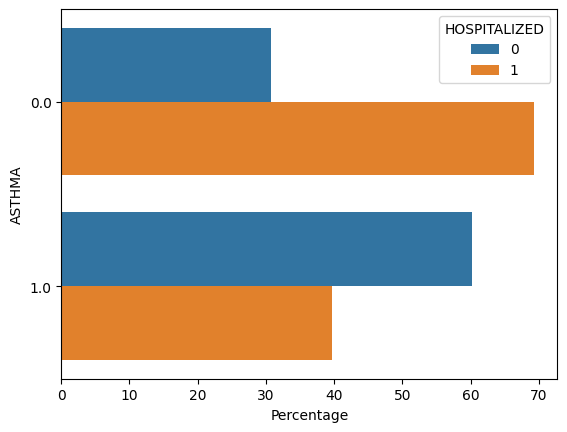

In [7]:
percentage_data = covid.groupby("ASTHMA")['HOSPITALIZED'].value_counts(normalize=True).mul(100).round(2)
percentage_data = percentage_data.reset_index(name='Percentage')
sns.barplot(data=percentage_data, y="ASTHMA", x="Percentage", hue="HOSPITALIZED", orient='h')

In [13]:
perform_chi_square_test(covid, 'HOSPITALIZED', 'IMMUNOSUPPRESSED')

H1: Analizowane zmienne są zależne.
p-value = 9.226509388872899e-34
Chi2 = 146.68
IMMUNOSUPPRESSED    0.0   1.0
HOSPITALIZED                 
0                 34451  1773
1                 73281  2578


IMMUNOSUPPRESSED,0.0,1.0
HOSPITALIZED,,
0,34817.804377,1406.195623
1,72914.195623,2944.804377


In [14]:
calculate_Cramers_V(covid, 'HOSPITALIZED', 'IMMUNOSUPPRESSED')

IMMUNOSUPPRESSED
0.0    0.036949
1.0    0.183857
dtype: float64

<Axes: xlabel='Percentage', ylabel='IMMUNOSUPPRESSED'>

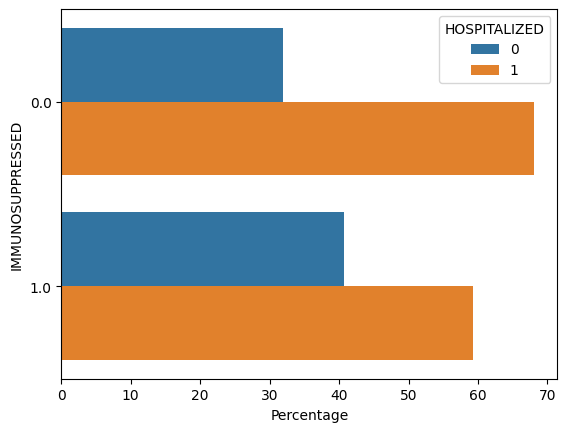

In [16]:
percentage_data = covid.groupby("IMMUNOSUPPRESSED")['HOSPITALIZED'].value_counts(normalize=True).mul(100).round(2)
percentage_data = percentage_data.reset_index(name='Percentage')
sns.barplot(data=percentage_data, y="IMMUNOSUPPRESSED", x="Percentage", hue="HOSPITALIZED", orient='h')

In [17]:
perform_chi_square_test(covid, 'HOSPITALIZED', 'PNEUMONIA')

H1: Analizowane zmienne są zależne.
p-value = 0.0
Chi2 = 24874.88
PNEUMONIA       0.0    1.0
HOSPITALIZED              
0             29271   7526
1             22705  53782


PNEUMONIA,0.0,1.0
HOSPITALIZED,,
0,16882.886127,19914.113873
1,35093.113873,41393.886127


In [18]:
calculate_Cramers_V(covid, 'HOSPITALIZED', 'PNEUMONIA')

PNEUMONIA
0.0    0.691826
1.0    0.637000
dtype: float64

<Axes: xlabel='Percentage', ylabel='PNEUMONIA'>

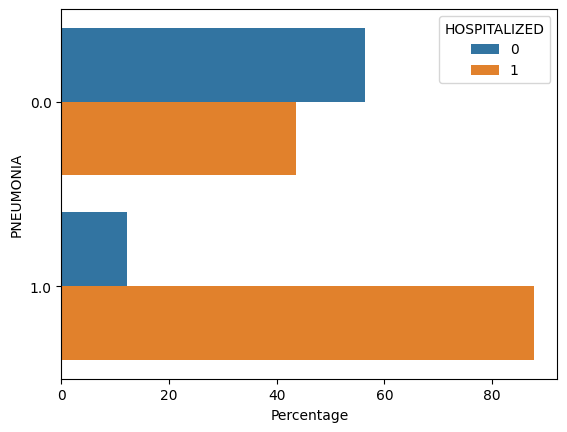

In [19]:
percentage_data = covid.groupby("PNEUMONIA")['HOSPITALIZED'].value_counts(normalize=True).mul(100).round(2)
percentage_data = percentage_data.reset_index(name='Percentage')
sns.barplot(data=percentage_data, y="PNEUMONIA", x="Percentage", hue="HOSPITALIZED", orient='h')

In [20]:
perform_chi_square_test(covid, 'HOSPITALIZED', 'PREGNANT')

H1: Analizowane zmienne są zależne.
p-value = 2.2330091714534838e-36
Chi2 = 158.65
PREGNANT        0.0  1.0
HOSPITALIZED            
0             16693  596
1             29128  484


PREGNANT,0.0,1.0
HOSPITALIZED,,
0,16890.882263,398.117737
1,28930.117737,681.882263


In [21]:
calculate_Cramers_V(covid, 'HOSPITALIZED', 'PREGNANT')

PREGNANT
0.0    0.058991
1.0    0.384242
dtype: float64

<Axes: xlabel='Percentage', ylabel='PREGNANT'>

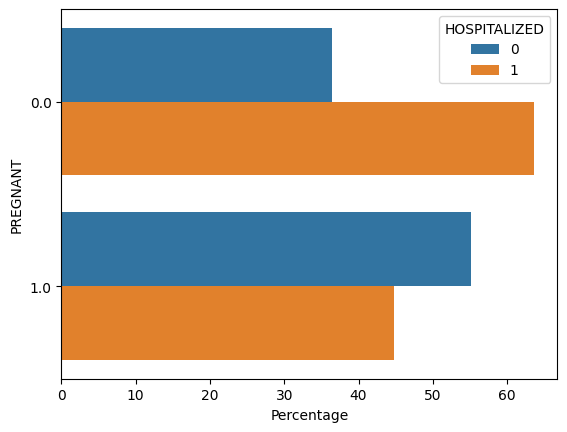

In [22]:
percentage_data = covid.groupby("PREGNANT")['HOSPITALIZED'].value_counts(normalize=True).mul(100).round(2)
percentage_data = percentage_data.reset_index(name='Percentage')
sns.barplot(data=percentage_data, y="PREGNANT", x="Percentage", hue="HOSPITALIZED", orient='h')